# Analysis of Experimental Condition Distributions in LS Splits

This notebook analyzes how the **LS (Large Scaffold) split** affects the distribution of experimental conditions between the training and test sets.

We analyze the following experimental conditions:

- **Instrument type**
- **Adduct type**
- **Collision energy**

This provides an indicataion that the difficulty of this split is due to distribution shifts in these conditions.

The workflow of this notebook is as follows:

1. Load processed spectral metadata for each dataset.
2. Compute and cache summary statistics for experimental conditions in both the training and test sets.
3. Compare the distributions of:
   - instrument types
   - adduct types
   - collision energy bins
4. Perform **Chi-square tests** to determine whether the differences between train and test distributions are statistically significant.
5. Visualize the distributions to better understand how LS splits may introduce additional covariate shifts.

The analysis is performed on the following datasets:

- **NPLIB1**
- **MassSpecGym**

Understanding these shifts helps determine whether model performance differences are influenced by **changes in experimental conditions** across the dataset splits.

Import libraries

In [42]:
import os 
import collections
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency

from utils import load_pickle, pickle_data, load_json

Settings

In [10]:
data_folder = Path("../data/processed_data")
splits_folder = Path("../data/splits")
cache_folder = Path("../results/LS_split_characteristics_analysis")
if not os.path.exists(cache_folder): os.makedirs(cache_folder)

datasets = ["NPLIB1", "massspecgym"]

instrument_colors = [ "#916953", "#B2675E", "#C4A381", "#F5ECCD", "#D6F6DD",]
adduct_colors = ["#0D5C63","#44A1A0", "#A8C7BB", "#C4F4C7"]
energy_colors = hex_colors = [
    "#e7e3d8",
    "#4b2c1a",
    "#a2753e",
    "#4d5c3d",
    "#b88e68",
    "#d1ac82",
    "#ceb29d",
    "#d4c3bc",
    "#dac2a6",
    "#98acab",
    "#bdc9bf",
    "#f7f6f4"]


Helper Functions

In [11]:
def get_instrument_breakdown(train_data, test_data, key = "instrument_type"):
        
    train_instruments = collections.Counter([r[key] for r in train_data])
    test_instruments = collections.Counter([r[key] for r in test_data])

    unique_instruments = set(list(train_instruments.keys()) + list(test_instruments.keys()))

    train_instrument_counts = [train_instruments[i] if i in train_instruments else 0 for i in unique_instruments]
    test_instrument_counts = [test_instruments[i] if i in test_instruments else 0 for i in unique_instruments]

    return (train_instruments,train_instrument_counts), (test_instruments, test_instrument_counts), unique_instruments

def get_adduct_breakdown(train_data, test_data):
                
    train_adducts = collections.Counter([r["precursor_type"] for r in train_data])
    test_adducts = collections.Counter([r["precursor_type"] for r in test_data])

    unique_adducts = set(list(train_adducts.keys()) + list(test_adducts.keys()))

    train_adduct_counts = [train_adducts[i] if i in train_adducts else 0 for i in unique_adducts]
    test_adduct_counts = [test_adducts[i] if i in test_adducts else 0 for i in unique_adducts]

    return (train_adducts, train_adduct_counts), (test_adducts, test_adduct_counts), unique_adducts

def get_energy_breakdown(train_data, test_data):

    train_energies = collections.Counter([r["collision_energy"] for r in train_data])
    test_energies = collections.Counter([r["collision_energy"] for r in test_data])

    energy_bins = ["-", "0-20", "20-40", "40-60", "60-80", "80-100", "100-120", "120-150", ">150"]
    train_energies_binned = {b: 0 for b in energy_bins}
    test_energies_binned = {b: 0 for b in energy_bins}
    
    for e,c in train_energies.items():

        if e == "-": train_energies_binned["-"] += c 
        elif e is None: train_energies_binned["-"] += c
        elif e < 20: train_energies_binned["0-20"] += c 
        elif e < 40: train_energies_binned["20-40"] += c 
        elif e < 60: train_energies_binned["40-60"] += c 
        elif e < 80: train_energies_binned["60-80"] += c 
        elif e < 100: train_energies_binned["80-100"] += c 
        elif e < 120: train_energies_binned["100-120"] += c 
        elif e < 150: train_energies_binned["120-150"] += c 
        else: train_energies_binned[">150"] += c 

    for e,c in test_energies.items():

        if e == "-": test_energies_binned["-"] += c 
        elif e is None: test_energies_binned["-"] += c
        elif e < 20: test_energies_binned["0-20"] += c 
        elif e < 40: test_energies_binned["20-40"] += c 
        elif e < 60: test_energies_binned["40-60"] += c 
        elif e < 80: test_energies_binned["60-80"] += c 
        elif e < 100: test_energies_binned["80-100"] += c 
        elif e < 120: test_energies_binned["100-120"] += c 
        elif e < 150: test_energies_binned["120-150"] += c 
        else: test_energies_binned[">150"] += c 

    train_binned_energy_counts = [train_energies_binned[i] for i in test_energies_binned.keys()]
    test_binned_energy_counts = [test_energies_binned[i] for i in test_energies_binned.keys()]

    return (train_energies_binned, train_binned_energy_counts), (test_energies_binned, test_binned_energy_counts), energy_bins

Step 1: Obtain statistics to understand characteristics of the LS split

In [22]:
for dataset in datasets:

    output_path = cache_folder / f"{dataset}_expt_conditions_breakdown.pkl"
    if os.path.exists(output_path): 
        print(f"Cache for statistics of experimental conditions for {dataset} created. Skipping.")
        continue

    # Load the data 
    data_path = data_folder / f"{dataset}.pkl"
    data = load_pickle(data_path)
    print(f"Loaded data: {dataset}")

    # Load the LS split 
    split_ids = load_json(splits_folder / dataset / f"LS.json")
    train_ids = [str(t.replace(".pkl", "")) for t in split_ids["train"]]
    test_ids = [str(t.replace(".pkl", "")) for t in split_ids["test"]]

    # Get the train and test data
    train_data = [rec for rec in data if str(rec["id_"]) in train_ids]
    test_data = [rec for rec in data if str(rec["id_"]) in test_ids]
    
    # Cache the breakdown of experimental conditions for train vs test
    instrument_key = "instrument_type"
    stats = {} 
    stats["instrument_breakdown"]  = get_instrument_breakdown(train_data, test_data, key = instrument_key)
    stats["adduct_breakdown"] = get_adduct_breakdown(train_data, test_data)
    stats["energy_breakdown"] = get_energy_breakdown(train_data, test_data)

    # Add to the data 
    pickle_data(stats, output_path)

Loaded data: NPLIB1
Loaded data: massspecgym


Step 2a: Analyze how the distribution of (1) instruments differs between the training and test sets

p_value NPLIB1 2.708655185767752e-08



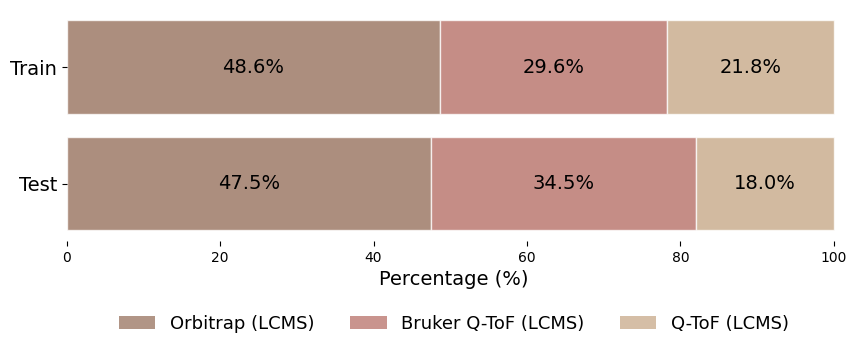

p_value massspecgym 0.0



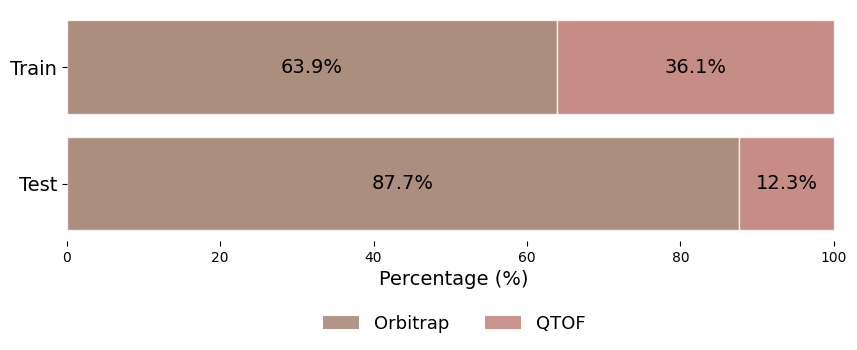

In [24]:
results_instruments = {}

# Choose your palette
color_palette = instrument_colors

for dataset in datasets:

    results_instruments[dataset] = {}

    stats = load_pickle(cache_folder / f"{dataset}_expt_conditions_breakdown.pkl")
    (train_inst_breakdown, _), (test_inst_breakdown, _), _ = stats["instrument_breakdown"]
    
    unique_instruments = list(set(train_inst_breakdown) | set(test_inst_breakdown))
    unique_instruments = [u for u in unique_instruments if u is not None and "Unknown" not in u]

    # Filter some of the low frequency instruments
    if dataset == "NPLIB1":
        unique_instruments = [u for u in unique_instruments if "Ion Trap" not in u and "FTICR" not in u]
    if dataset == "massspecgym":
        unique_instruments = [u for u in unique_instruments if u is not None]

    # Normalize to percentage
    train_total = sum(train_inst_breakdown.get(u, 0) for u in unique_instruments)
    test_total = sum(test_inst_breakdown.get(u, 0) for u in unique_instruments)

    train_inst_count = {u: train_inst_breakdown.get(u, 0) for u in unique_instruments}
    test_inst_count = {u: test_inst_breakdown.get(u, 0) for u in unique_instruments}

    train_inst_percent = {u: train_inst_breakdown.get(u, 0) / train_total * 100 if train_total > 0 else 0 for u in unique_instruments}
    test_inst_percent = {u: test_inst_breakdown.get(u, 0) / test_total * 100 if test_total > 0 else 0 for u in unique_instruments}

    data = pd.DataFrame({
        'Train': list(train_inst_count.values()),
        'Test': list(test_inst_count.values()),
    }, list(test_inst_count.keys()))

    print("p_value", dataset, chi2_contingency(data)[1])
    print()

    unique_instruments = sorted(unique_instruments, key=lambda u: train_inst_percent.get(u, 0), reverse = True)
    results_instruments[dataset]["counts"] = test_inst_breakdown

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 3))
    bar_positions = [0, 1]  # 0 = Train, 1 = Test
    left_train, left_test = 0, 0
    
    for i, instrument in enumerate(unique_instruments):
        
        color = color_palette[i % len(color_palette)]
        train_val = train_inst_percent[instrument]
        test_val = test_inst_percent[instrument]

        # Train bar
        ax.barh(bar_positions[0], train_val, left=left_train, color=color, edgecolor='white', alpha = 0.75)
        if train_val > 3:
            ax.text(left_train + train_val / 2, bar_positions[0], f"{train_val:.1f}%", ha='center', va='center', fontsize=14)
        left_train += train_val

        # Test bar
        ax.barh(bar_positions[1], test_val, left=left_test, color=color, edgecolor='white', alpha = 0.75)
        if test_val > 3:
            ax.text(left_test + test_val / 2, bar_positions[1], f"{test_val:.1f}%", ha='center', va='center', fontsize=14)
        left_test += test_val

    # Customize axis
    ax.grid(False)
    ax.set_yticks(bar_positions)
    ax.set_yticklabels(["Train", "Test"], fontsize=14)
    ax.set_xlim(0, 101)
    ax.set_xlabel("Percentage (%)", fontsize=14)

    # Legend
    legend_labels = unique_instruments

    # Match legend labels to colors
    legend_patches = [Patch(facecolor=color_palette[i % len(color_palette)],
                            label=u,
                            alpha=0.7)
                            for i, u in enumerate(unique_instruments)]

    ax.legend(labels = legend_labels, handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.25),
                ncol=len(legend_labels), fontsize=13, frameon=False)

    ax.invert_yaxis()  # Train on top
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    plt.show()

Step 2b: Analyze how the distribution of (2) adduct differs between the training and test sets

p_value NPLIB1 7.693875492471923e-09



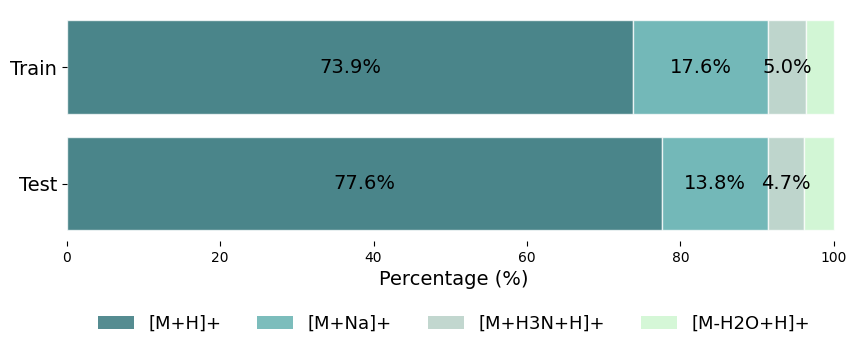

p_value massspecgym 1.5604221199750835e-68



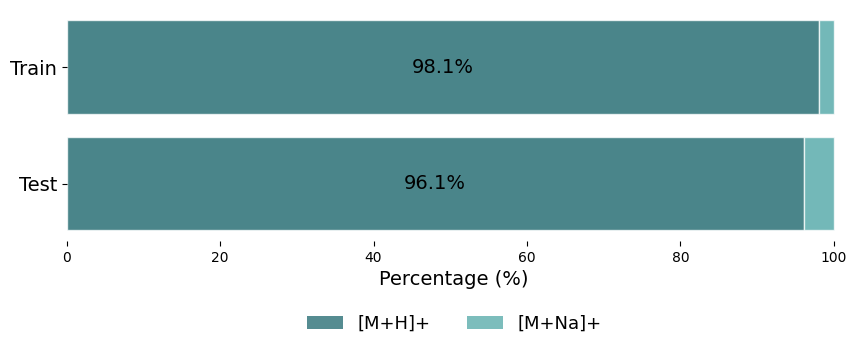

In [31]:
results_adduct = {}

# Choose your palette
color_palette = adduct_colors

for dataset in datasets:

    results_adduct[dataset] = {}

    stats = load_pickle(cache_folder / f"{dataset}_expt_conditions_breakdown.pkl")
    (train_adduct_breakdown, _), (test_adduct_breakdown, _), _ = stats["adduct_breakdown"]
    
    unique_adducts = list(set(list(train_adduct_breakdown.keys()) + list(test_adduct_breakdown.keys())))

    # Filter some of the low frequency adducts
    if dataset == "NPLIB1": unique_adducts = [u for u in unique_adducts if "[M]+" not in u and "[M+K]+" not in u]

    # Normalize to percentage
    train_total = sum(train_adduct_breakdown.get(u, 0) for u in unique_adducts)
    test_total = sum(test_adduct_breakdown.get(u, 0) for u in unique_adducts)

    train_adduct_count = {u: train_adduct_breakdown.get(u, 0) for u in unique_adducts}
    test_adduct_count = {u: test_adduct_breakdown.get(u, 0) for u in unique_adducts}

    train_adduct_percent = {u: train_adduct_breakdown.get(u, 0) / train_total * 100 if train_total > 0 else 0 for u in unique_adducts}
    test_adduct_percent = {u: test_adduct_breakdown.get(u, 0) / test_total * 100 if test_total > 0 else 0 for u in unique_adducts}

    data = pd.DataFrame({
        'Train': list(train_adduct_count.values()),
        'Test': list(test_adduct_count.values()),
    }, list(test_adduct_count.keys()))

    print("p_value", dataset, chi2_contingency(data)[1])
    print()

    selected_adducts = sorted(unique_adducts, key=lambda u: train_adduct_percent.get(u, 0), reverse = True)
    results_adduct[dataset]["counts"] = test_inst_breakdown
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 3))
    bar_positions = [0, 1]  # 0 = Train, 1 = Test
    left_train = 0
    left_test = 0

    for i, adduct in enumerate(selected_adducts):
        
        color = color_palette[i % len(color_palette)]
        train_val = train_adduct_percent[adduct]
        test_val = test_adduct_percent[adduct]

        # Train bar
        ax.barh(bar_positions[0], train_val, left=left_train, color=color, edgecolor='white', alpha = 0.75)
        if train_val > 4:
            ax.text(left_train + train_val / 2, bar_positions[0], f"{train_val:.1f}%", ha='center', va='center', fontsize=14)
        left_train += train_val

        # Test bar
        ax.barh(bar_positions[1], test_val, left=left_test, color=color, edgecolor='white', alpha = 0.75)
        if test_val > 4:
            ax.text(left_test + test_val / 2, bar_positions[1], f"{test_val:.1f}%", ha='center', va='center', fontsize=14)
        left_test += test_val

    # Customize axis
    ax.grid(False)
    ax.set_yticks(bar_positions)
    ax.set_yticklabels(["Train", "Test"], fontsize=14)
    ax.set_xlim(0, 101)
    ax.set_xlabel("Percentage (%)", fontsize=14)

    legend_labels = selected_adducts

    # Match legend labels to colors
    legend_patches = [Patch(facecolor=color_palette[i % len(color_palette)],
                            label=u,
                            alpha=0.7)
                            for i, u in enumerate(selected_adducts)]

    ax.legend(labels = legend_labels, handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.25),
                ncol=len(legend_labels), fontsize=13, frameon=False)

    ax.invert_yaxis()  # Train on top
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    plt.show()

Step 2c: Analyze how the distribution of (3) collision energy differs between the training and test sets

p_value NPLIB1 2.0830826285696248e-18


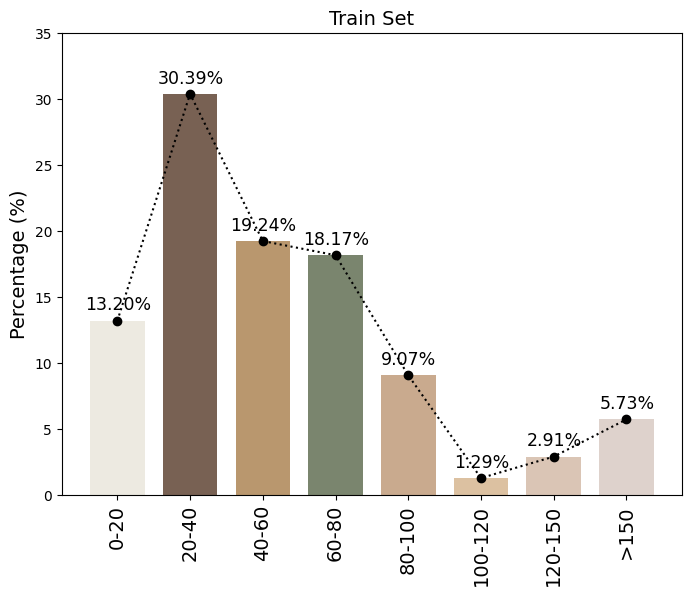

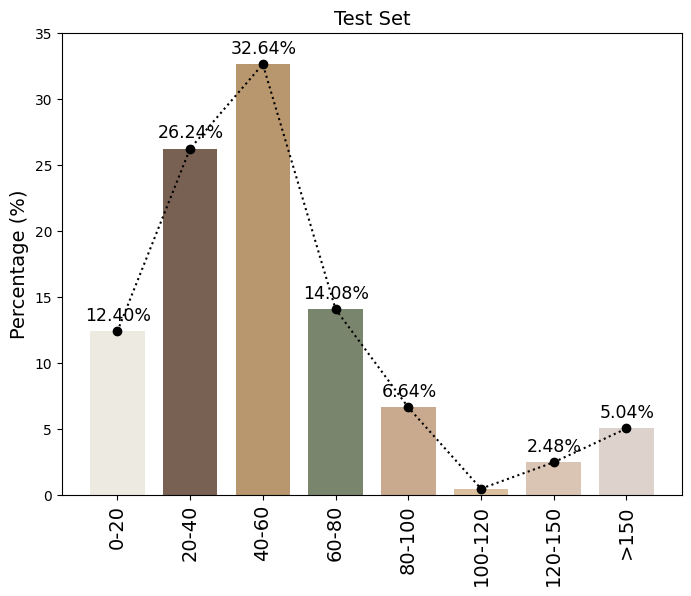

p_value massspecgym 0.0


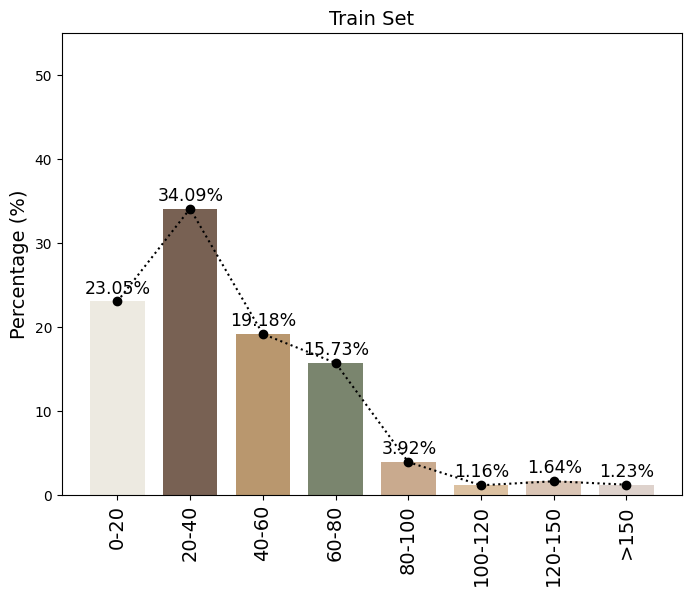

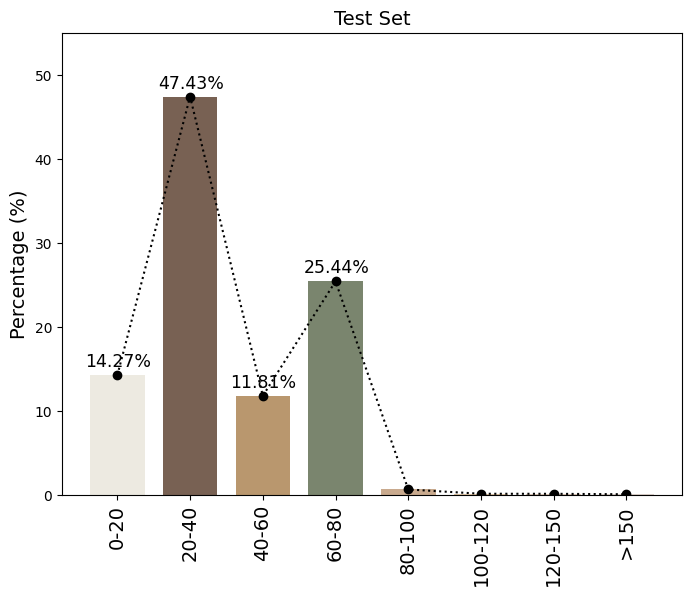

In [41]:
results_energy = {} 

# Choose your palette
color_palette = adduct_colors

for dataset in datasets:

    results_energy[dataset] = {} 
    if dataset == "NPLIB1": vmax = 35 
    if dataset == "massspecgym": vmax = 55

    stats = load_pickle(cache_folder / f"{dataset}_expt_conditions_breakdown.pkl")

    energy_bins = ["0-20", "20-40", "40-60", "60-80", "80-100", "100-120", "120-150", ">150"]
    (train_binned_energy_breakdown, _), (test_binned_energy_breakdown, _), _ = stats["energy_breakdown"]
    train_binned_energy_counts = {e: train_binned_energy_breakdown[e] for e in energy_bins}
    test_binned_energy_counts = {e: test_binned_energy_breakdown[e] for e in energy_bins}
    n_train = sum(train_binned_energy_counts.values())
    n_test = sum(test_binned_energy_counts.values())

    train_binned_energy_percent = {e: train_binned_energy_counts[e] / n_train * 100 for e in energy_bins}
    test_binned_energy_percent = {e: test_binned_energy_counts[e] / n_test * 100 for e in energy_bins}
    
    data = pd.DataFrame({
        'Train': list(train_binned_energy_counts.values()),
        'Test': list(test_binned_energy_counts.values()),
    }, list(train_binned_energy_counts.keys()))
    
    print("p_value", dataset, chi2_contingency(data)[1])

    results_energy[dataset]["counts"] = test_binned_energy_counts

    selected_energy_bins = energy_bins
    x = np.arange(len(selected_energy_bins))

    # Bar plot (Train)
    plt.figure(figsize=(8, 6))
    bar_width = 0.75
    
    plt.bar(x, [train_binned_energy_percent[e] for e in selected_energy_bins],
            bar_width, label="Train", alpha=0.75, color = energy_colors)
    
    for xi, val in zip(x, train_binned_energy_percent.values()):
        if val > 1:  # Optional: show only if >1%
            plt.text(xi + 0.01, val + 0.5, f"{val:.2f}%", ha='center', va='bottom', fontsize=12.5)
            
    # Curve overlay
    plt.plot(x, [train_binned_energy_percent[e] for e in selected_energy_bins],
                color='black', marker='o', linestyle='dotted', label="Train (Curve)")

    # Formatting
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.xticks(x, selected_energy_bins, fontsize=14, rotation=90)
    plt.ylim([0, vmax])

    plt.title(f"Train Set", fontsize=14)
    plt.show()

    # Bar plot (Test)
    plt.figure(figsize=(8, 6))
    bar_width = 0.75
    
    plt.bar(x, [test_binned_energy_percent[e] for e in selected_energy_bins],
            bar_width, label="Train", alpha=0.75, color = energy_colors)

    for xi, val in zip(x, test_binned_energy_percent.values()):
        if val > 1:  # Optional: show only if >1%
            plt.text(xi + 0.01, val + 0.5, f"{val:.2f}%", ha='center', va='bottom', fontsize=12.5)

    # Curve overlay
    plt.plot(x, [test_binned_energy_percent[e] for e in selected_energy_bins],
                color='black', marker='o', linestyle='dotted', label="Train (Curve)")

    # Formatting
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.xticks(x, selected_energy_bins, fontsize=14, rotation=90)
    plt.ylim([0, vmax])

    plt.title(f"Test Set", fontsize=14)
    plt.show()
